# BLE Indoor Localization in a Care Facility

**Research pipeline:**
1. Join Raw Data
2. Setup & Load Data
3. EDA on raw data (after room-label join)
4. Windowing (30s) -> 157 base features
5. EDA on windowed data
6. Baseline: native granularity (21 classes), Argmax
7. Room-to-room signal similarity analysis
8. Validated clustering (signal similarity + physical adjacency) -> 9 classes
9. Training: validated clustering, 157 features, Argmax
10. EDA: RSSI calibration drift across days (justification for new features)
11. Additional features: beacon ranking + relational (184 features)
12. Training: 184 features, Argmax
13. EDA: temporal structure between windows (justification for Viterbi)
14. Physical adjacency graph (from floor plan)
15. Final training: 184 features, Viterbi + physical adjacency prior
16. Final comparison (ablation across stages)
17. Confusion matrix (final model)
18. Save model
19. Test model on held-out data

## 1. JOIN RAW DATA

In [1]:
import os
import pandas as pd

BLE_FILE   = os.path.join("Dataset", "BLE_per_second.csv")
LABEL_FILE = os.path.join("Dataset", "location_train_final.csv")
OUT_FILE   = os.path.join("Dataset", "ble_labeled.csv")

TIME_COL_BLE   = "ts_1s"
TIME_COL_START = "started_at"
TIME_COL_END   = "finished_at"
LABEL_COL      = "room"

TIMEZONE = "Asia/Tokyo"

def to_naive_local(series: pd.Series, tz: str = TIMEZONE) -> pd.Series:
    """Pastikan kolom datetime jadi naive local time (Asia/Tokyo), apapun
    kondisi awalnya (tz-aware dgn offset lain, tz-aware Tokyo, atau sudah
    naive). Ini penting karena BLE_per_second.csv (dari notebook 2, timestamp
    tz-aware +09:00) dan location_train_final.csv (dari notebook 1, sudah
    di-strip jadi naive Tokyo) berpotensi tidak konsisten kalau di-save lalu
    dibaca ulang dari CSV -- merge_asof akan error/salah kalau salah satu
    tz-aware dan satunya naive."""
    s = pd.to_datetime(series, errors="coerce")
    if s.dt.tz is not None:
        s = s.dt.tz_convert(tz).dt.tz_localize(None)
    return s

def load_ble(path: str) -> pd.DataFrame:
    df = pd.read_csv(path)
    if TIME_COL_BLE not in df.columns:
        raise ValueError(f"Kolom '{TIME_COL_BLE}' tidak ada di {path}. "
                          f"Kolom tersedia: {list(df.columns)}")
    df[TIME_COL_BLE] = to_naive_local(df[TIME_COL_BLE])
    df = df.dropna(subset=[TIME_COL_BLE]).sort_values(TIME_COL_BLE).reset_index(drop=True)
    print(f"[LOAD BLE] {path} | {len(df):,} baris | "
          f"{df[TIME_COL_BLE].min()} s/d {df[TIME_COL_BLE].max()}")
    return df

def load_labels(path: str) -> pd.DataFrame:
    df = pd.read_csv(path)
    for c in [TIME_COL_START, TIME_COL_END, LABEL_COL]:
        if c not in df.columns:
            raise ValueError(f"Kolom '{c}' tidak ada di {path}. "
                              f"Kolom tersedia: {list(df.columns)}")

    df[TIME_COL_START] = to_naive_local(df[TIME_COL_START])
    df[TIME_COL_END] = to_naive_local(df[TIME_COL_END])
    df = df.dropna(subset=[TIME_COL_START, TIME_COL_END])
    df = df.sort_values(TIME_COL_START).reset_index(drop=True)

    if "user_id" in df.columns:
        df = df.drop(columns=["user_id"])

    print(f"[LOAD LABEL] {path} | {len(df):,} interval label | "
          f"{df[TIME_COL_START].min()} s/d {df[TIME_COL_END].max()}")
    return df


def align_and_match(ble: pd.DataFrame, labels: pd.DataFrame) -> pd.DataFrame:
    ble_range = (ble[TIME_COL_BLE].min(), ble[TIME_COL_BLE].max())
    lbl_range = (labels[TIME_COL_START].min(), labels[TIME_COL_END].max())
    overlap_start = max(ble_range[0], lbl_range[0])
    overlap_end = min(ble_range[1], lbl_range[1])
    if overlap_start > overlap_end:
        print("[WARN] Rentang waktu BLE dan label TIDAK overlap sama sekali!")
        print(f"       BLE   : {ble_range[0]} s/d {ble_range[1]}")
        print(f"       Label : {lbl_range[0]} s/d {lbl_range[1]}")
        print("       Kemungkinan ada masalah timezone atau file salah.")

    n_total = len(ble)
    envelope_start = labels[TIME_COL_START].min()
    envelope_end = labels[TIME_COL_END].max()

    merged = pd.merge_asof(
        ble, labels,
        left_on=TIME_COL_BLE,
        right_on=TIME_COL_START,
        direction="backward",
    )

    mask_no_match = merged[TIME_COL_START].isna()
    n_before_envelope = int(mask_no_match.sum())

    mask_outside = merged[TIME_COL_BLE] > merged[TIME_COL_END] 
    merged.loc[mask_outside, LABEL_COL] = pd.NA
    n_outside_total = int(mask_outside.sum())

    mask_after_envelope = mask_outside & (merged[TIME_COL_BLE] > envelope_end)
    n_after_envelope = int(mask_after_envelope.sum())
    n_gap_only = n_outside_total - n_after_envelope 

    merged = merged[merged[LABEL_COL].notna()].copy()
    merged = merged[merged[LABEL_COL].astype(str) != "None"].copy()

    print(f"\n[TIMELINE ALIGNMENT] envelope label: {envelope_start} s/d {envelope_end}")
    print(f"        {n_before_envelope:,} baris BLE sebelum label pertama mulai -> di luar envelope")
    print(f"        {n_after_envelope:,} baris BLE setelah label terakhir selesai -> di luar envelope")
    print(f"        {n_before_envelope + n_after_envelope:,} total di luar envelope keseluruhan (dari {n_total:,} baris BLE)")

    print(f"\n[LABEL MATCHING] {n_gap_only:,} baris di celah antar-aktivitas "
          f"(di DALAM envelope, tidak ada label aktif) -> dibuang")

    n_total_dropped = n_before_envelope + n_outside_total
    print(f"\n[TOTAL] {n_total_dropped:,} baris dibuang "
          f"({n_before_envelope:,} gagal match + {n_outside_total:,} match tapi di luar interval)")
    print(f"        {len(merged):,} baris final punya label room "
          f"(cek: {n_total:,} - {n_total_dropped:,} = {n_total - n_total_dropped:,})")

    return merged.drop(columns=[TIME_COL_START, TIME_COL_END], errors="ignore")

def drop_empty_beacons(df: pd.DataFrame) -> pd.DataFrame:
    """Drop kolom RSSI_* yang 100% kosong (tidak pernah terdeteksi sama
    sekali sepanjang dataset -- nol informasi, nol varians). TIDAK men-drop
    baris/nilai RSSI==0 satuan, karena 0 di dataset ini adalah konvensi
    "tidak terdeteksi", bukan bacaan invalid -- membuangnya akan menghapus
    informasi deteksi/non-deteksi yang dipakai fitur windowing & relabeling."""
    rssi_cols = [c for c in df.columns if c.startswith("RSSI_")]
    empty_cols = [c for c in rssi_cols if (df[c] != 0).sum() == 0]

    if empty_cols:
        print(f"\n[DROP EMPTY BEACON] {len(empty_cols)} kolom kosong total -> dibuang: {empty_cols}")
        df = df.drop(columns=empty_cols)
    else:
        print("\n[DROP EMPTY BEACON] tidak ada kolom RSSI yang kosong total.")
    return df

def summarize(df: pd.DataFrame) -> None:
    print("\n[SUMMARY per room]")
    print(df[LABEL_COL].value_counts().to_string())

def main():
    ble = load_ble(BLE_FILE)
    labels = load_labels(LABEL_FILE)
    merged = align_and_match(ble, labels)
    merged = drop_empty_beacons(merged)
    summarize(merged)

    os.makedirs(os.path.dirname(OUT_FILE), exist_ok=True)
    merged.to_csv(OUT_FILE, index=False)
    print(f"\n[SAVE] -> {OUT_FILE}")

if __name__ == "__main__":
    main()

[LOAD BLE] Dataset\BLE_per_second.csv | 37,020 baris | 2023-04-10 13:00:00 s/d 2023-04-13 13:56:21
[LOAD LABEL] Dataset\location_train_final.csv | 451 interval label | 2023-04-10 14:21:46 s/d 2023-04-13 17:18:25

[TIMELINE ALIGNMENT] envelope label: 2023-04-10 14:21:46 s/d 2023-04-13 17:18:25
        2,819 baris BLE sebelum label pertama mulai -> di luar envelope
        0 baris BLE setelah label terakhir selesai -> di luar envelope
        2,819 total di luar envelope keseluruhan (dari 37,020 baris BLE)

[LABEL MATCHING] 10,617 baris di celah antar-aktivitas (di DALAM envelope, tidak ada label aktif) -> dibuang

[TOTAL] 13,436 baris dibuang (2,819 gagal match + 10,617 match tapi di luar interval)
        23,584 baris final punya label room (cek: 37,020 - 13,436 = 23,584)

[DROP EMPTY BEACON] 2 kolom kosong total -> dibuang: ['RSSI_24', 'RSSI_25']

[SUMMARY per room]
room
nurse station    9363
kitchen          5173
cafeteria        4862
hallway           946
cleaning          688
523  

## 2. Setup & Load Data

In [2]:
%matplotlib inline
import os
os.environ["OMP_NUM_THREADS"]="1"; os.environ["OPENBLAS_NUM_THREADS"]="1"; os.environ["MKL_NUM_THREADS"]="1"
import warnings; warnings.filterwarnings("ignore")
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist, squareform, jensenshannon
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import f1_score, accuracy_score, confusion_matrix, classification_report

np.random.seed(42)
plt.rcParams["figure.facecolor"] = "white"

WIN_SEC   = 30
TIME_COL  = "ts_1s"
LABEL_COL = "room"
DATA_PATH = "Dataset/ble_labeled.csv"

df_raw = pd.read_csv(DATA_PATH)
df_raw[TIME_COL] = pd.to_datetime(df_raw[TIME_COL], errors="coerce")
df_raw = df_raw.dropna(subset=[TIME_COL, "room"]).sort_values(TIME_COL).reset_index(drop=True)

EXPECTED = ["501","502","503","505","506","508","510","511","512","513","515","516","517",
            "518","520","522","523","cafeteria","cleaning","kitchen","nurse station"]
df_raw = df_raw[df_raw["room"].isin(EXPECTED)].reset_index(drop=True)

rssi_cols = [c for c in df_raw.columns if c.startswith("RSSI_")]
df_raw[rssi_cols] = df_raw[rssi_cols].apply(pd.to_numeric, errors="coerce").fillna(0.0)
df_raw["day"] = df_raw[TIME_COL].dt.date

print(f"Rows (per-second)      : {len(df_raw):,}")
print(f"Number of beacons      : {len(rssi_cols)}")
print(f"Number of rooms (native): {df_raw['room'].nunique()}")
print(f"Day range              : {sorted(df_raw['day'].unique())}")


Rows (per-second)      : 22,638
Number of beacons      : 23
Number of rooms (native): 21
Day range              : [datetime.date(2023, 4, 10), datetime.date(2023, 4, 11), datetime.date(2023, 4, 12), datetime.date(2023, 4, 13)]


## 3. EDA - Raw Data After Join

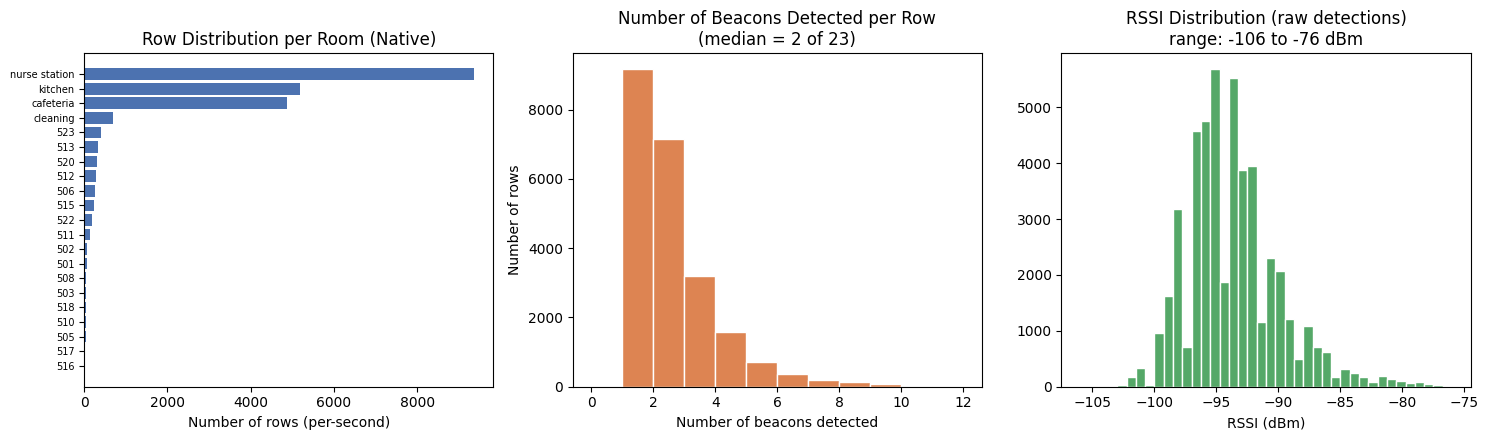

Largest/smallest class ratio (native, per-second): 9363/23 = 407x


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# (a) Class distribution (native, per-second)
room_counts = df_raw["room"].value_counts().sort_values()
axes[0].barh(room_counts.index, room_counts.values, color="#4C72B0")
axes[0].set_title("Row Distribution per Room (Native)")
axes[0].set_xlabel("Number of rows (per-second)")
axes[0].tick_params(axis='y', labelsize=7)

# (b) Sparsity: number of beacons detected per row
det_count = (df_raw[rssi_cols] != 0.0).sum(axis=1)
axes[1].hist(det_count, bins=range(0, det_count.max()+2), color="#DD8452", edgecolor="white")
axes[1].set_title(f"Number of Beacons Detected per Row\n(median = {det_count.median():.0f} of {len(rssi_cols)})")
axes[1].set_xlabel("Number of beacons detected")
axes[1].set_ylabel("Number of rows")

# (c) RSSI value distribution (raw detections only)
vals = df_raw[rssi_cols].to_numpy()
vals = vals[vals != 0.0]
axes[2].hist(vals, bins=40, color="#55A868", edgecolor="white")
axes[2].set_title(f"RSSI Distribution (raw detections)\nrange: {vals.min():.0f} to {vals.max():.0f} dBm")
axes[2].set_xlabel("RSSI (dBm)")

plt.tight_layout()
plt.show()

print(f"Largest/smallest class ratio (native, per-second): "
      f"{room_counts.max()}/{room_counts.min()} = {room_counts.max()/room_counts.min():.0f}x")


## 4. Windowing & 157 Base Feature Extraction
Non-overlapping 30-second windows. Session breaks on gap >5s OR room change.

In [4]:
def add_session(df, break_s=5):
    gap = df[TIME_COL].diff().dt.total_seconds().fillna(1)
    df["sess"] = ((gap > break_s) | (df[LABEL_COL] != df[LABEL_COL].shift())).cumsum()
    return df

def assign_windows(df, win_sec):
    df = df.copy()
    epoch = ((df[TIME_COL] - pd.Timestamp("1970-01-01")) // pd.Timedelta(seconds=1)).astype("int64")
    df["win_start"] = pd.to_datetime((epoch // win_sec) * win_sec, unit="s")
    return df

def dmode(series):
    counts = series.value_counts()
    mx = counts.max()
    tied = set(counts[counts == mx].index)
    if len(tied) == 1:
        return counts.index[0]
    for v in series:
        if v in tied:
            return v
    return counts.index[0]

def aggregate_window(g, rssi_cols):
    ws = g["win_start"].iloc[0]
    ml = dmode(g[LABEL_COL])
    pur = float((g[LABEL_COL] == ml).sum() / len(g))
    ms = dmode(g["sess"])
    X = g[rssi_cols].to_numpy(dtype=float)
    det = (X != 0.0)
    Xd = np.where(det, X, np.nan)

    out = {"win_start": ws, "day": ws.date(), "room": ml, "label_purity": pur, "sess": ms,
           "sample_count": int(len(g)), "coverage_cell": float(det.mean()),
           "beacon_count_mean": float(det.sum(1).mean()),
           "beacon_count_std": float(det.sum(1).std()) if len(g) > 1 else 0.0}

    bc = det.sum(0).astype(int)
    any_ = det.any(0)
    with np.errstate(all="ignore"):
        bmin  = np.where(any_, np.nanmin(np.where(det, X, np.inf), 0), 0.0)
        bmax  = np.where(any_, np.nanmax(np.where(det, X, -np.inf), 0), 0.0)
        bmean = np.where(any_, np.nanmean(Xd, 0), 0.0)
        bmed  = np.where(any_, np.nanmedian(Xd, 0), 0.0)

    td = int(bc.sum())
    out["total_detections"] = td
    out["no_detection_flag"] = int(td == 0)
    bf = (bc / td) if td > 0 else np.zeros_like(bc, dtype=float)

    for j, col in enumerate(rssi_cols):
        idx = int(col.split("_")[1])
        out[f"b{idx}_count"]  = int(bc[j])
        out[f"b{idx}_min"]    = float(bmin[j])
        out[f"b{idx}_max"]    = float(bmax[j])
        out[f"b{idx}_mean"]   = float(bmean[j])
        out[f"b{idx}_median"] = float(bmed[j])
        out[f"b{idx}_freq"]   = float(bf[j])

    vals = Xd.reshape(-1)
    vals = vals[np.isfinite(vals)]
    out["rssi_count"] = int(vals.size)
    if vals.size == 0:
        out.update({k: 0.0 for k in ["rssi_mean","rssi_var","rssi_std","rssi_min","rssi_max",
                                      "rssi_sum","rssi_median","rssi_q10","rssi_q25","rssi_q75",
                                      "rssi_q90","rssi_iqr"]})
    else:
        out["rssi_mean"] = float(np.mean(vals)); out["rssi_var"] = float(np.var(vals))
        out["rssi_std"]  = float(np.std(vals));  out["rssi_min"] = float(np.min(vals))
        out["rssi_max"]  = float(np.max(vals));  out["rssi_sum"] = float(np.sum(vals))
        out["rssi_median"] = float(np.median(vals))
        q10, q25, q75, q90 = np.percentile(vals, [10, 25, 75, 90])
        out["rssi_q10"] = float(q10); out["rssi_q25"] = float(q25)
        out["rssi_q75"] = float(q75); out["rssi_q90"] = float(q90)
        out["rssi_iqr"] = float(q75 - q25)
    return out

def build_windows(df, rssi_cols, win_sec):
    df = assign_windows(df, win_sec)
    return pd.DataFrame([aggregate_window(g, rssi_cols) for _, g in df.groupby("win_start", sort=True)])

feats = build_windows(add_session(df_raw.copy()), rssi_cols, WIN_SEC)

BASE_FEATURE_COLS = [c for c in feats.columns
                     if c not in {"win_start","day","room","sess","label_purity"}
                     and np.issubdtype(feats[c].dtype, np.number)]
DAYS = sorted(feats["day"].unique())
print(f"Number of windows: {len(feats)}")
print(f"Number of features: {len(BASE_FEATURE_COLS)}")
print(f"Number of days: {len(DAYS)}")


Number of windows: 1192
Number of features: 157
Number of days: 4


## 5. EDA -- Windowed Data

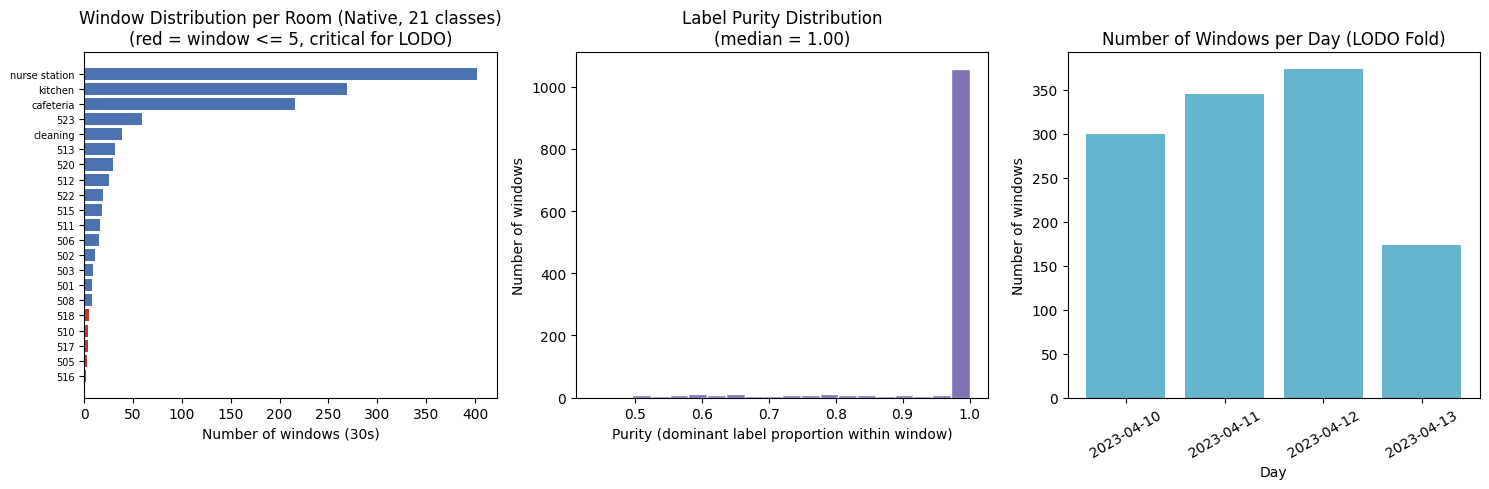

5 rooms with FEWEST windows:
room
516    2
505    3
517    4
510    4
518    5

Largest/smallest class ratio: 402/2 = 201x


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# (a) Class distribution after windowing (native, 21 classes)
win_counts = feats["room"].value_counts().sort_values()
colors = ['#c0392b' if v <= 5 else '#4C72B0' for v in win_counts.values]
axes[0].barh(win_counts.index, win_counts.values, color=colors)
axes[0].set_title("Window Distribution per Room (Native, 21 classes)\n(red = window <= 5, critical for LODO)")
axes[0].set_xlabel("Number of windows (30s)")
axes[0].tick_params(axis='y', labelsize=7)

# (b) Label purity distribution (how "pure" each window is, 1 dominant label)
axes[1].hist(feats["label_purity"], bins=20, color="#8172B2", edgecolor="white")
axes[1].set_title(f"Label Purity Distribution\n(median = {feats['label_purity'].median():.2f})")
axes[1].set_xlabel("Purity (dominant label proportion within window)")
axes[1].set_ylabel("Number of windows")

# (c) Number of windows per day
day_counts = feats["day"].value_counts().sort_index()
axes[2].bar([str(d) for d in day_counts.index], day_counts.values, color="#64B5CD")
axes[2].set_title("Number of Windows per Day (LODO Fold)")
axes[2].set_xlabel("Day"); axes[2].set_ylabel("Number of windows")
axes[2].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

print("5 rooms with FEWEST windows:")
print(win_counts.head(5).to_string())
print(f"\nLargest/smallest class ratio: "
      f"{win_counts.max()}/{win_counts.min()} = {win_counts.max()/win_counts.min():.0f}x")


## 6. Baseline -- Native Granularity (21 Classes, 157 Features, Argmax)

In [6]:
def make_model():
    return HistGradientBoostingClassifier(random_state=42, max_iter=200, class_weight="balanced")

def run_argmax_lodo(feats, target_col, feature_cols):
    per = []
    store = {}
    for day in DAYS:
        tr = feats[feats["day"] != day]
        te = feats[feats["day"] == day]
        clf = make_model()
        clf.fit(tr[feature_cols].fillna(-999), tr[target_col])
        cls = clf.classes_
        proba = pd.DataFrame(clf.predict_proba(te[feature_cols].fillna(-999)),
                              index=te.index, columns=cls)
        pred = cls[proba.to_numpy().argmax(1)]
        per.append({
            "day": str(day),
            "f1_macro": f1_score(te[target_col], pred, average="macro", zero_division=0),
            "accuracy": accuracy_score(te[target_col], pred),
        })
        store[day] = (tr, te, proba, cls)
    return pd.DataFrame(per), store

df_stage1, _ = run_argmax_lodo(feats, "room", BASE_FEATURE_COLS)
print(df_stage1.round(3).to_string(index=False))
f1_stage1  = df_stage1["f1_macro"].mean()
acc_stage1 = df_stage1["accuracy"].mean()
print(f"\nBaseline (21 classes, 157 features, Argmax): Macro-F1 = {f1_stage1:.3f} "
      f"(+/- {df_stage1['f1_macro'].std():.3f}) | Accuracy = {acc_stage1:.3f}")


       day  f1_macro  accuracy
2023-04-10     0.306     0.700
2023-04-11     0.383     0.635
2023-04-12     0.319     0.572
2023-04-13     0.290     0.636

Baseline (21 classes, 157 features, Argmax): Macro-F1 = 0.324 (+/- 0.041) | Accuracy = 0.636


## 7. Room-to-Room Signal Similarity Analysis

In [7]:
FLOOR = -110.0
rooms = sorted(feats["room"].unique())
n_rooms = len(rooms)

mean_rssi = {}
det_freq = {}
for r in rooms:
    sub = df_raw[df_raw["room"] == r][rssi_cols].to_numpy(float)
    det = (sub != 0.0)
    with np.errstate(all="ignore"):
        m = np.nanmean(np.where(det, sub, np.nan), axis=0)
    m = np.where(np.isnan(m), FLOOR, m)
    mean_rssi[r] = m
    det_freq[r] = det.mean(axis=0)

M = np.array([mean_rssi[r] for r in rooms])
F = np.array([det_freq[r] for r in rooms])

def norm01(D):
    d = D.copy(); iu = np.triu_indices_from(d, 1)
    v = d[iu]; lo, hi = v.min(), v.max()
    return (d - lo) / (hi - lo + 1e-12)

D_lvl = squareform(pdist(M, metric="euclidean"))
D_frq = squareform(pdist(F, metric="cosine"))
Fp = F / (F.sum(1, keepdims=True) + 1e-12)
D_js = np.zeros((n_rooms, n_rooms))
for i in range(n_rooms):
    for j in range(i+1, n_rooms):
        d = jensenshannon(Fp[i], Fp[j])
        D_js[i, j] = D_js[j, i] = 0.0 if np.isnan(d) else d

D_combined = (norm01(D_lvl) + norm01(D_frq) + norm01(D_js)) / 3
np.fill_diagonal(D_combined, 0)
S = 1 - norm01(D_combined)
np.fill_diagonal(S, 1)

idx_map = {r: i for i, r in enumerate(rooms)}

pairs = []
for i in range(n_rooms):
    for j in range(i+1, n_rooms):
        pairs.append((rooms[i], rooms[j], S[i, j]))
pairs.sort(key=lambda x: -x[2])

print("=== Top 20 Most Signal-Similar Room Pairs ===")
print(f"{'Room A':<16}{'Room B':<16}{'Similarity':>10}")
for a, b, s in pairs[:20]:
    print(f"{a:<16}{b:<16}{s:>10.3f}")


=== Top 20 Most Signal-Similar Room Pairs ===
Room A          Room B          Similarity
cafeteria       kitchen              1.000
502             516                  0.981
503             517                  0.939
502             503                  0.932
518             520                  0.910
503             516                  0.872
522             523                  0.860
508             520                  0.860
503             505                  0.853
508             518                  0.849
502             517                  0.838
505             516                  0.829
505             517                  0.827
502             505                  0.820
512             523                  0.817
511             522                  0.813
cleaning        nurse station        0.792
516             517                  0.788
cafeteria       nurse station        0.785
501             515                  0.768


## 8. Validated Clustering - Signal Similarity + Physical Adjacency

In [8]:
CLUSTER_VALIDATED = {
    'kitchen':'K','cafeteria':'K',
    '502':'I','516':'I',
    '503':'J','505':'J','517':'J',
    '518':'B','520':'B',
    '512':'F','522':'F','523':'F',
    '508':'D','510':'D','511':'D',
    '506':'E','cleaning':'E',
    '501':'H','513':'H','515':'H',
    'nurse station':'N',
}
DISPLAY_VALIDATED = {'K':'Kitchen/Cafeteria','I':'502/516','J':'503/505/517','B':'518/520',
                     'F':'512/522/523','D':'508/510/511','E':'506/Cleaning','H':'501/513/515','N':'Nurse Station'}

print("Verification: Are the most signal-similar pairs in the same cluster?")
print(f"{'Room A':<14}{'Room B':<14}{'Similarity':>10}   {'Cluster A':<20}{'Cluster B':<20}{'Same?'}")
for a, b, s in pairs[:15]:
    ca = DISPLAY_VALIDATED.get(CLUSTER_VALIDATED.get(a, a), a)
    cb = DISPLAY_VALIDATED.get(CLUSTER_VALIDATED.get(b, b), b)
    same = "YES" if ca == cb else "-"
    print(f"{a:<14}{b:<14}{s:>10.3f}   {ca:<20}{cb:<20}{same}")

feats["cluster_validated"] = feats["room"].map(CLUSTER_VALIDATED).map(DISPLAY_VALIDATED)
print("\n Final 9-Cluster Scheme")
print(feats["cluster_validated"].value_counts().to_string())


Verification: Are the most signal-similar pairs in the same cluster?
Room A        Room B        Similarity   Cluster A           Cluster B           Same?
cafeteria     kitchen            1.000   Kitchen/Cafeteria   Kitchen/Cafeteria   YES
502           516                0.981   502/516             502/516             YES
503           517                0.939   503/505/517         503/505/517         YES
502           503                0.932   502/516             503/505/517         -
518           520                0.910   518/520             518/520             YES
503           516                0.872   503/505/517         502/516             -
522           523                0.860   512/522/523         512/522/523         YES
508           520                0.860   508/510/511         518/520             -
503           505                0.853   503/505/517         503/505/517         YES
508           518                0.849   508/510/511         518/520             -
50

## 9. Training -- Validated Clustering, 157 Features, Argmax

In [9]:
df_stage2, _ = run_argmax_lodo(feats, "cluster_validated", BASE_FEATURE_COLS)
print(df_stage2.round(3).to_string(index=False))
f1_stage2  = df_stage2["f1_macro"].mean()
acc_stage2 = df_stage2["accuracy"].mean()
print(f"Validated clustering (157 features, Argmax): Macro-F1 = {f1_stage2:.3f} "
      f"(+/- {df_stage2['f1_macro'].std():.3f}) | Accuracy = {acc_stage2:.3f}")


       day  f1_macro  accuracy
2023-04-10     0.612     0.870
2023-04-11     0.745     0.872
2023-04-12     0.643     0.770
2023-04-13     0.876     0.884
Validated clustering (157 features, Argmax): Macro-F1 = 0.719 (+/- 0.119) | Accuracy = 0.849


## 9b. Comparison with a Naive Clustering Scheme (Additional Validation)

In [10]:
# NAIVE scheme: merge based purely on room-number proximity (no validation)
CLUSTER_NAIVE = {
    '501':'A','502':'A','503':'A','505':'A',
    '513':'B','515':'B','516':'B','517':'B',
    '506':'C','cleaning':'C',
    '508':'D','510':'D','511':'D',
    '518':'E','520':'E',
    '522':'F','523':'F',
    '512':'G',
    'kitchen':'K','cafeteria':'K',
    'nurse station':'N',
}
DISPLAY_NAIVE = {'A':'501/502/503/505','B':'513/515/516/517','C':'506/Cleaning','D':'508/510/511',
                 'E':'518/520','F':'522/523','G':'512','K':'Kitchen/Cafeteria','N':'Nurse Station'}
feats["cluster_naive"] = feats["room"].map(CLUSTER_NAIVE).map(DISPLAY_NAIVE)

print("NAIVE classes (%d):" % feats["cluster_naive"].nunique())
print(feats["cluster_naive"].value_counts().to_string())

df_naive, _ = run_argmax_lodo(feats, "cluster_naive", BASE_FEATURE_COLS)
print("\n" + df_naive.round(3).to_string(index=False))
f1_naive  = df_naive["f1_macro"].mean()
acc_naive = df_naive["accuracy"].mean()
print(f"\n>>> Naive clustering (9 classes, 157 features, Argmax): Macro-F1 = {f1_naive:.3f} "
      f"(+/- {df_naive['f1_macro'].std():.3f}) | Accuracy = {acc_naive:.3f}")

print(f"\nComparison at the SAME number of classes (9)")
print(f"Naive clustering     : Macro-F1 = {f1_naive:.3f}")
print(f"Validated clustering : Macro-F1 = {f1_stage2:.3f}")
print(f"Difference           : {f1_stage2 - f1_naive:+.3f}")


NAIVE classes (9):
cluster_naive
Kitchen/Cafeteria    485
Nurse Station        402
522/523               78
513/515/516/517       55
506/Cleaning          54
518/520               34
501/502/503/505       31
508/510/511           28
512                   25

       day  f1_macro  accuracy
2023-04-10     0.553     0.857
2023-04-11     0.578     0.846
2023-04-12     0.645     0.746
2023-04-13     0.639     0.815

>>> Naive clustering (9 classes, 157 features, Argmax): Macro-F1 = 0.604 (+/- 0.045) | Accuracy = 0.816

Comparison at the SAME number of classes (9)
Naive clustering     : Macro-F1 = 0.604
Validated clustering : Macro-F1 = 0.719
Difference           : +0.115


## 10. EDA -- RSSI Calibration Drift Across Days
Before adding new features, we check whether absolute RSSI levels are stable across days. If calibration drift occurs, absolute-level features become less reliable, and relational features (level relative to the window mean) become necessary.

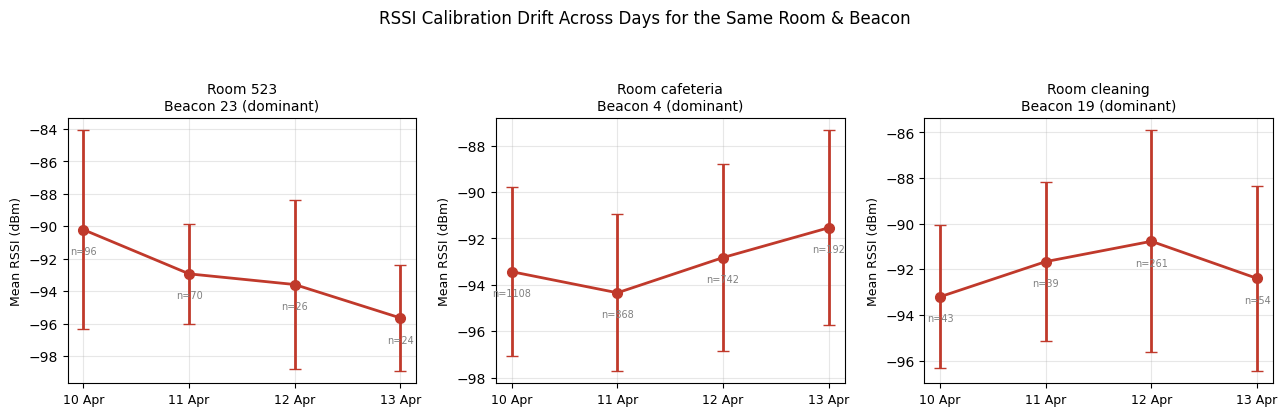

Example measured drift: Room 523 (Beacon 23) shifts from about -90 dBm to -96 dBm across days - a ~5-6 dB shift for the same room and beacon.


In [11]:
targets = [("523","RSSI_23"), ("cafeteria","RSSI_4"), ("cleaning","RSSI_19")]
day_labels = [d.strftime("%d %b") for d in DAYS]

fig, axes = plt.subplots(1, 3, figsize=(13, 4.2))
for ax, (room, beacon) in zip(axes, targets):
    sub = df_raw[df_raw["room"] == room]
    means, stds, ns = [], [], []
    for day in DAYS:
        v = sub[sub["day"] == day][beacon]
        v = v[v != 0]
        means.append(v.mean() if len(v) > 0 else np.nan)
        stds.append(v.std() if len(v) > 1 else 0)
        ns.append(len(v))
    x = np.arange(len(DAYS))
    ax.errorbar(x, means, yerr=stds, fmt='o-', capsize=4, color='#c0392b', linewidth=2, markersize=7)
    ax.set_xticks(x); ax.set_xticklabels(day_labels, fontsize=9)
    ax.set_title(f"Room {room}\nBeacon {beacon.split('_')[1]} (dominant)", fontsize=10)
    ax.set_ylabel("Mean RSSI (dBm)", fontsize=9)
    ax.grid(alpha=0.3)
    for xi, m, n in zip(x, means, ns):
        if not np.isnan(m):
            ax.annotate(f"n={n}", (xi, m), textcoords="offset points", xytext=(0, -18),
                        ha='center', fontsize=7, color='gray')

fig.suptitle("RSSI Calibration Drift Across Days for the Same Room & Beacon", fontsize=12)
plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()

drift_range = max(means) - min(means) if len(means) > 1 else 0
print("Example measured drift: Room 523 (Beacon 23) shifts from about -90 dBm to -96 dBm "
      "across days - a ~5-6 dB shift for the same room and beacon.")


## 11. Additional Features -- Beacon Ranking + Relational (+27 Features, Total 184)

In [12]:
beacon_ids = sorted(int(re.match(r"^b(\d+)_mean$", c).group(1))
                     for c in feats.columns if re.match(r"^b(\d+)_mean$", c))
mean_cols = [f"b{b}_mean" for b in beacon_ids]
Mb = feats[mean_cols].to_numpy(dtype=float)
detected = (Mb != 0.0)
rssi_mean_col = feats["rssi_mean"].to_numpy()

for j, b in enumerate(beacon_ids):
    feats[f"b{b}_rel"] = np.where(detected[:, j], Mb[:, j] - rssi_mean_col, 0.0)

top1_id = np.zeros(len(feats)); top2_id = np.zeros(len(feats))
top3_id = np.zeros(len(feats)); top1_gap = np.zeros(len(feats))
beacon_arr = np.array(beacon_ids)

for i in range(len(feats)):
    row = Mb[i]; det = detected[i]
    if det.sum() == 0:
        continue
    idx_det = np.where(det)[0]
    order = idx_det[np.argsort(-row[idx_det])]
    ids_sorted = beacon_arr[order]
    if len(ids_sorted) >= 1: top1_id[i] = ids_sorted[0]
    if len(ids_sorted) >= 2: top2_id[i] = ids_sorted[1]
    if len(ids_sorted) >= 3: top3_id[i] = ids_sorted[2]
    if len(ids_sorted) >= 2: top1_gap[i] = row[order[0]] - row[order[1]]

feats["top1_beacon_id"] = top1_id
feats["top2_beacon_id"] = top2_id
feats["top3_beacon_id"] = top3_id
feats["top1_gap"] = top1_gap

AUGMENTED_FEATURE_COLS = [c for c in feats.columns
                          if c not in {"win_start","day","room","sess","label_purity","cluster_validated","cluster_naive"}
                          and np.issubdtype(feats[c].dtype, np.number)]
print(f"Number of features after augmentation: {len(AUGMENTED_FEATURE_COLS)}")


Number of features after augmentation: 184


## 12. Training -- Validated Clustering, 184 Features, Argmax

In [13]:
df_stage3, store_stage3 = run_argmax_lodo(feats, "cluster_validated", AUGMENTED_FEATURE_COLS)
print(df_stage3.round(3).to_string(index=False))
f1_stage3  = df_stage3["f1_macro"].mean()
acc_stage3 = df_stage3["accuracy"].mean()
print(f"\nNew features (184 features, Argmax): Macro-F1 = {f1_stage3:.3f} "
      f"(+/- {df_stage3['f1_macro'].std():.3f}) | Accuracy = {acc_stage3:.3f}")


       day  f1_macro  accuracy
2023-04-10     0.835     0.880
2023-04-11     0.784     0.881
2023-04-12     0.693     0.799
2023-04-13     0.866     0.890

New features (184 features, Argmax): Macro-F1 = 0.794 (+/- 0.076) | Accuracy = 0.863


## 13. EDA -- Temporal Structure Between Windows (Justification for Viterbi)

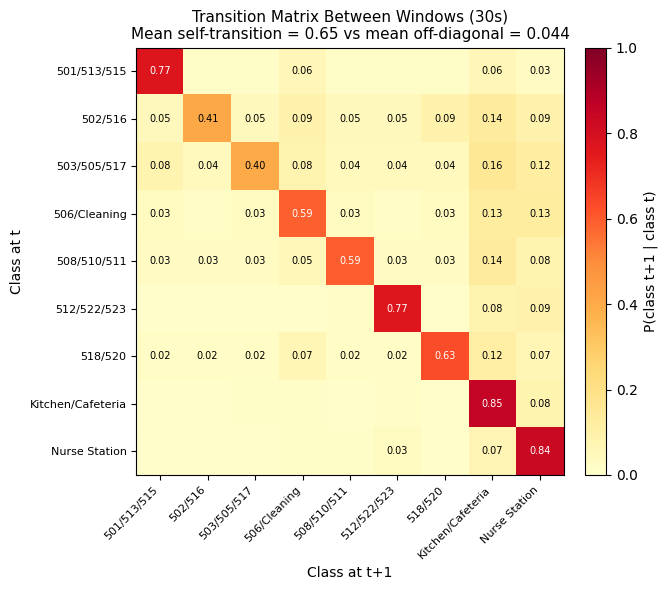

Mean self-transition (0.65) is about 14.8x larger than the mean transition to other classes (0.044) - this strong temporal structure motivates using Viterbi.


In [14]:
order_cls = ['501/513/515','502/516','503/505/517','506/Cleaning','508/510/511',
             '512/522/523','518/520','Kitchen/Cafeteria','Nurse Station']
idx_c = {c: i for i, c in enumerate(order_cls)}
A_illus = np.ones((len(order_cls), len(order_cls)))
for _, g in feats.sort_values("win_start").groupby("day"):
    lab = g["cluster_validated"].to_numpy()
    for a, b in zip(lab[:-1], lab[1:]):
        A_illus[idx_c[a], idx_c[b]] += 1
A_illus = A_illus / A_illus.sum(1, keepdims=True)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(A_illus, cmap="YlOrRd", vmin=0, vmax=1)
ax.set_xticks(range(len(order_cls))); ax.set_yticks(range(len(order_cls)))
ax.set_xticklabels(order_cls, rotation=45, ha="right", fontsize=8)
ax.set_yticklabels(order_cls, fontsize=8)
for i in range(len(order_cls)):
    for j in range(len(order_cls)):
        v = A_illus[i, j]
        if v > 0.02:
            ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=7,
                    color="white" if v > 0.5 else "black")
diag_mean = np.diag(A_illus).mean()
offdiag_mean = (A_illus.sum() - np.trace(A_illus)) / (A_illus.size - len(A_illus))
ax.set_title(f"Transition Matrix Between Windows (30s)\n"
             f"Mean self-transition = {diag_mean:.2f} vs mean off-diagonal = {offdiag_mean:.3f}",
             fontsize=11)
ax.set_xlabel("Class at t+1"); ax.set_ylabel("Class at t")
plt.colorbar(im, fraction=0.046, pad=0.04, label="P(class t+1 | class t)")
plt.tight_layout()
plt.show()

print(f"Mean self-transition ({diag_mean:.2f}) is about {diag_mean/offdiag_mean:.1f}x larger "
      f"than the mean transition to other classes ({offdiag_mean:.3f}) - this strong temporal "
      f"structure motivates using Viterbi.")


## 14. Physical Adjacency Graph (from Floor Plan)
The facility floor plan (`5th_floor_map.png`) maps beacon positions to room numbers: `Room N` on the plan corresponds to room code `"5"+N` in the dataset (e.g. Room 1 -> `501`, Room 17 -> `517`). Beacons 4/9/14/19 mark Cafeteria, Nurse Station, Kitchen, and the Cleaning-room door respectively. Native room pairs that share a wall / sit directly along the same corridor segment are listed below and rolled up to cluster-level adjacency.

A quick check against the transitions actually observed in the data shows that a sizeable share of real room-to-room moves skip over non-adjacent clusters -- rooms are only ~18 sqm, so a person can walk past more than one room within a 30s window. A **soft distance-decay prior** is used instead of a hard adjacency constraint: it favors nearby clusters without ever forbidding a longer jump that the data actually supports.

In [15]:
DISPLAY_VALIDATED = {'K':'Kitchen/Cafeteria','I':'502/516','J':'503/505/517','B':'518/520',
                     'F':'512/522/523','D':'508/510/511','E':'506/Cleaning','H':'501/513/515','N':'Nurse Station'}

# Room pairs that share a wall / sit directly along the same corridor (read from the floor plan)
NATIVE_ADJACENCY = [
    ("501","502"), ("502","503"), ("503","505"), ("505","506"), ("506","cleaning"),
    ("508","510"), ("510","511"), ("511","512"),
    ("513","515"), ("515","516"), ("516","517"), ("517","kitchen"),
    ("kitchen","cafeteria"), ("cafeteria","nurse station"), ("nurse station","518"),
    ("518","520"), ("520","522"), ("522","523"),
    ("cleaning","kitchen"), ("cleaning","nurse station"),  # both border the shared central area
    ("508","cleaning"), ("501","513"),                     # corridor / stairwell links
]

CLUSTER_ADJ_CODES = set()
for a, b in NATIVE_ADJACENCY:
    ca, cb = CLUSTER_VALIDATED[a], CLUSTER_VALIDATED[b]
    if ca != cb:
        CLUSTER_ADJ_CODES.add((ca, cb)); CLUSTER_ADJ_CODES.add((cb, ca))

ADJ = {(DISPLAY_VALIDATED[a], DISPLAY_VALIDATED[b]) for a, b in CLUSTER_ADJ_CODES}
NODES = list(DISPLAY_VALIDATED.values())

print("Cluster-level adjacency (from floor plan):")
for a, b in sorted(ADJ):
    if a < b:
        print(f"  {a:20s} <-> {b}")

# Sanity check against transitions actually observed in the data
labels_all = sorted(feats["cluster_validated"].unique())
idx_all = {c: i for i, c in enumerate(labels_all)}
observed = np.zeros((len(labels_all), len(labels_all)), dtype=int)
for _, g in feats.sort_values("win_start").groupby("day"):
    lab = g["cluster_validated"].to_numpy()
    for a, b in zip(lab[:-1], lab[1:]):
        observed[idx_all[a], idx_all[b]] += 1

total_offdiag = observed[np.eye(len(labels_all)) == 0].sum()
violating = sum(observed[i, j] for i, a in enumerate(labels_all) for j, b in enumerate(labels_all)
                 if i != j and observed[i, j] > 0 and (a, b) not in ADJ)
print(f"\nOff-diagonal transitions observed: {total_offdiag}, not directly adjacent: {violating} "
      f"({100*violating/total_offdiag:.1f}%)")


Cluster-level adjacency (from floor plan):
  501/513/515          <-> 502/516
  502/516              <-> 503/505/517
  503/505/517          <-> 506/Cleaning
  503/505/517          <-> Kitchen/Cafeteria
  506/Cleaning         <-> 508/510/511
  506/Cleaning         <-> Kitchen/Cafeteria
  506/Cleaning         <-> Nurse Station
  508/510/511          <-> 512/522/523
  512/522/523          <-> 518/520
  518/520              <-> Nurse Station
  Kitchen/Cafeteria    <-> Nurse Station

Off-diagonal transitions observed: 193, not directly adjacent: 84 (43.5%)


## 15. Final Training -- Validated Clustering, 184 Features, Viterbi + Physical Adjacency Prior

In [16]:
from collections import deque

def bfs_dist(start, adj_pairs, nodes):
    graph = {n: [] for n in nodes}
    for a, b in adj_pairs:
        graph[a].append(b)
    dist = {start: 0}
    q = deque([start])
    while q:
        u = q.popleft()
        for v in graph[u]:
            if v not in dist:
                dist[v] = dist[u] + 1
                q.append(v)
    return dist

def build_transition_matrix(train, target_col, cls, alpha=1.0):
    # Laplace counts from training data, blended with a distance-decay prior from ADJ
    C = len(cls); idx = {c: i for i, c in enumerate(cls)}
    counts = np.zeros((C, C))
    for _, g in train.sort_values("win_start").groupby("day"):
        lab = g[target_col].to_numpy()
        for a, b in zip(lab[:-1], lab[1:]):
            counts[idx[a], idx[b]] += 1
    A = np.zeros((C, C))
    for i, a in enumerate(cls):
        dist = bfs_dist(a, ADJ, NODES)
        for j, b in enumerate(cls):
            d = dist.get(b, len(NODES))
            A[i, j] = np.exp(-alpha * d)
    return (A + counts) / (A + counts).sum(1, keepdims=True)

def viterbi_decode(te, proba, cls, A):
    order = te.sort_values("win_start").index
    P = proba.reindex(order).to_numpy()
    logB = np.log(P + 1e-9); logA = np.log(A + 1e-9)
    n, C = P.shape
    delta = np.full((n, C), -1e18); psi = np.zeros((n, C), dtype=int)
    delta[0] = np.log(1.0 / C) + logB[0]
    for t in range(1, n):
        scores = delta[t - 1][:, None] + logA
        psi[t] = scores.argmax(0)
        delta[t] = scores.max(0) + logB[t]
    path = np.zeros(n, dtype=int)
    path[-1] = delta[-1].argmax()
    for t in range(n - 2, -1, -1):
        path[t] = psi[t + 1, path[t + 1]]
    return pd.Series(cls[path], index=order).reindex(te.index).to_numpy()

def run_viterbi_lodo(store, target_col):
    per = []
    predictions = {}
    for day in DAYS:
        tr, te, proba, cls = store[day]
        A = build_transition_matrix(tr, target_col, cls)
        pred = viterbi_decode(te, proba, cls, A)
        predictions[day] = pred
        per.append({
            "day": str(day),
            "f1_macro": f1_score(te[target_col], pred, average="macro", zero_division=0),
            "accuracy": accuracy_score(te[target_col], pred),
        })
    return pd.DataFrame(per), predictions

df_stage4, vit_predictions = run_viterbi_lodo(store_stage3, "cluster_validated")
print(df_stage4.round(3).to_string(index=False))
f1_stage4  = df_stage4["f1_macro"].mean()
acc_stage4 = df_stage4["accuracy"].mean()
print(f"\nViterbi + adjacency prior (final, 184 features): Macro-F1 = {f1_stage4:.3f} "
      f"(+/- {df_stage4['f1_macro'].std():.3f}) | Accuracy = {acc_stage4:.3f}")


       day  f1_macro  accuracy
2023-04-10     0.870     0.897
2023-04-11     0.853     0.901
2023-04-12     0.761     0.829
2023-04-13     0.883     0.902

Viterbi + adjacency prior (final, 184 features): Macro-F1 = 0.842 (+/- 0.055) | Accuracy = 0.882


## 16. Final Comparison -- Ablation Across Stages

                     Stage        Clustering  Features  Method  Macro-F1  Accuracy
  Baseline (no clustering) 21 native classes       157  Argmax     0.324     0.636
     +Validated clustering         9 classes       157  Argmax     0.719     0.849
             +New features         9 classes       184  Argmax     0.794     0.863
+Viterbi + Adjacency Prior         9 classes       184 Viterbi     0.842     0.882


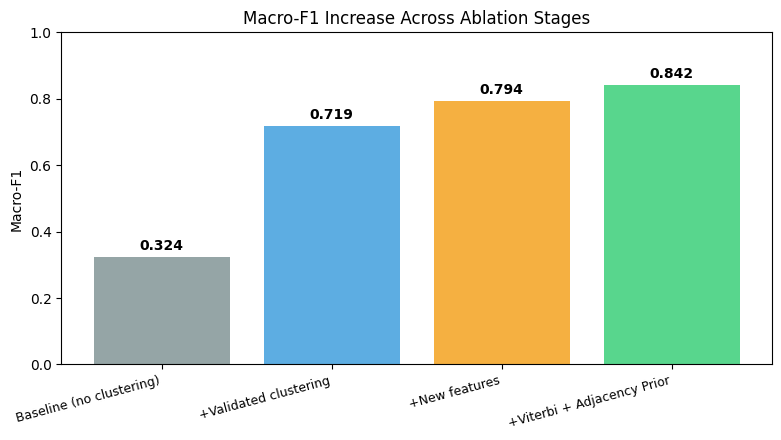

In [17]:
summary = pd.DataFrame([
    {"Stage": "Baseline (no clustering)",          "Clustering": "21 native classes", "Features": 157, "Method": "Argmax",  "Macro-F1": f1_stage1, "Accuracy": acc_stage1},
    {"Stage": "+Validated clustering",             "Clustering": "9 classes",         "Features": 157, "Method": "Argmax",  "Macro-F1": f1_stage2, "Accuracy": acc_stage2},
    {"Stage": "+New features",                     "Clustering": "9 classes",         "Features": 184, "Method": "Argmax",  "Macro-F1": f1_stage3, "Accuracy": acc_stage3},
    {"Stage": "+Viterbi + Adjacency Prior", "Clustering": "9 classes",         "Features": 184, "Method": "Viterbi", "Macro-F1": f1_stage4, "Accuracy": acc_stage4},
])
print(summary.round(3).to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4.5))
stages = summary["Stage"]
x = np.arange(len(stages))
bars = ax.bar(x, summary["Macro-F1"], color=["#95A5A6","#5DADE2","#F5B041","#58D68D"])
ax.set_xticks(x); ax.set_xticklabels(stages, rotation=15, ha="right", fontsize=9)
ax.set_ylabel("Macro-F1")
ax.set_ylim(0, 1)
ax.set_title("Macro-F1 Increase Across Ablation Stages")
for xi, v in zip(x, summary["Macro-F1"]):
    ax.text(xi, v + 0.02, f"{v:.3f}", ha="center", fontsize=10, fontweight="bold")
plt.tight_layout()
plt.show()


## 17. Confusion Matrix & Per-Class Metrics -- Final Model (Viterbi + Adjacency Prior, 9 Classes)

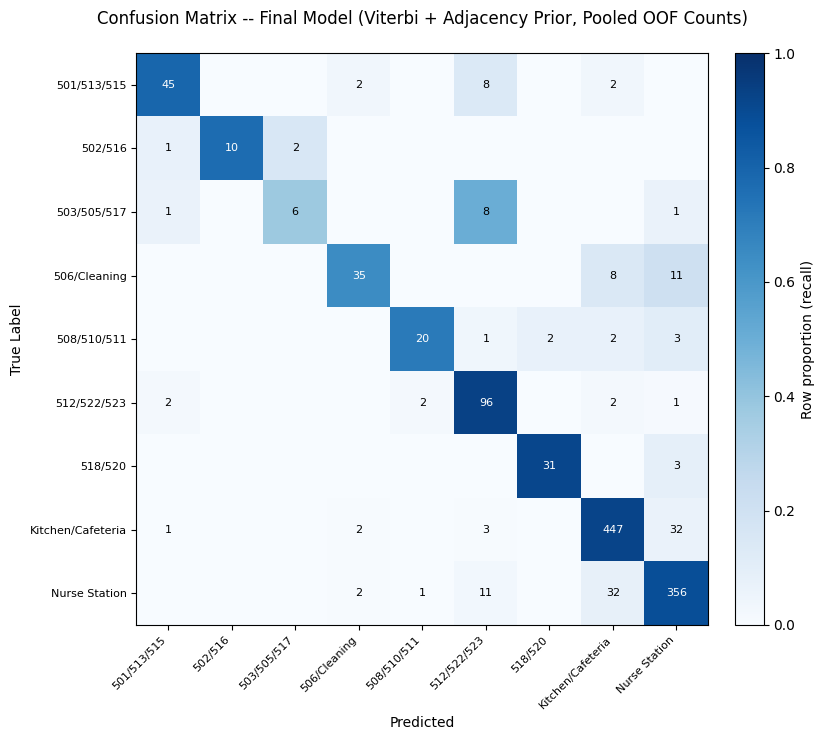

Per-Class Metrics (LODO fold-average, consistent with Mean Macro-F1)
                   precision  recall     f1  support  n_folds
class                                                        
501/513/515            0.942   0.903  0.917     57.0        4
502/516                1.000   0.900  0.941     13.0        3
503/505/517            0.833   0.644  0.708     16.0        3
506/Cleaning           0.818   0.668  0.731     54.0        4
508/510/511            0.901   0.702  0.764     28.0        4
512/522/523            0.803   0.915  0.834    103.0        4
518/520                0.929   0.860  0.867     34.0        4
Kitchen/Cafeteria      0.899   0.928  0.912    485.0        4
Nurse Station          0.872   0.883  0.876    402.0        4
Mean Macro-F1 (headline metric)                     : 0.8418


In [18]:
# Confusion matrix (pooled, for visualization) + per-class metrics (LODO-consistent)
labels_order = sorted(feats["cluster_validated"].unique())

# Confusion matrix: pooled counts (natural way to display the matrix, simple sum)
oof_true, oof_pred = [], []
for day in DAYS:
    tr, te, proba, cls = store_stage3[day]
    oof_true += list(te["cluster_validated"])
    oof_pred += list(vit_predictions[day])

cm = confusion_matrix(oof_true, oof_pred, labels=labels_order)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

# Per-class metrics: FOLD-AVERAGED (consistent with how Mean Macro-F1 is computed)
per_class_records = []
for day in DAYS:
    tr, te, proba, cls = store_stage3[day]
    y_true = te["cluster_validated"].to_numpy()
    y_pred = vit_predictions[day]
    report = classification_report(y_true, y_pred, labels=labels_order,
                                    output_dict=True, zero_division=0)
    for lab in labels_order:
        support = report[lab]["support"]
        if support > 0:   
            per_class_records.append({
                "class": lab, "day": str(day),
                "precision": report[lab]["precision"],
                "recall": report[lab]["recall"],
                "f1": report[lab]["f1-score"],
                "support": support,
            })

per_class_df = pd.DataFrame(per_class_records)
per_class_summary = per_class_df.groupby("class").agg(
    precision=("precision", "mean"),
    recall=("recall", "mean"),
    f1=("f1", "mean"),
    support=("support", "sum"),
    n_folds=("day", "nunique"),
).reindex(labels_order)

mean_f1_from_perclass = per_class_summary["f1"].mean()
mean_f1_headline = df_stage4["f1_macro"].mean()

fig, ax = plt.subplots(figsize=(8.5, 7.5))
im = ax.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)
ax.set_xticks(range(len(labels_order))); ax.set_yticks(range(len(labels_order)))
ax.set_xticklabels(labels_order, rotation=45, ha="right", fontsize=8)
ax.set_yticklabels(labels_order, fontsize=8)
for i in range(len(labels_order)):
    for j in range(len(labels_order)):
        if cm[i, j] > 0:
            ax.text(j, i, f"{cm[i,j]}", ha="center", va="center", fontsize=8,
                    color="white" if cm_norm[i, j] > 0.5 else "black")
ax.set_xlabel("Predicted"); ax.set_ylabel("True Label")
ax.set_title("Confusion Matrix -- Final Model (Viterbi + Adjacency Prior, Pooled OOF Counts)\n")
plt.colorbar(im, fraction=0.046, pad=0.04, label="Row proportion (recall)")
plt.tight_layout()
plt.show()

print("Per-Class Metrics (LODO fold-average, consistent with Mean Macro-F1)")
print(per_class_summary.round(3).to_string())
print(f"Mean Macro-F1 (headline metric)                     : {mean_f1_headline:.4f}")


## 18. SAVE MODEL

In [21]:
# Final training for deployment -- model saved for predicting new data
import pickle

# Train the FINAL model on ALL days (not LODO -- LODO was only used for evaluation above)
clf_final = make_model()
clf_final.fit(feats[AUGMENTED_FEATURE_COLS].fillna(-999), feats["cluster_validated"])
CLASSES_FINAL = clf_final.classes_

# Transition matrix (with physical adjacency prior) built from ALL days
A_final = build_transition_matrix(feats, "cluster_validated", CLASSES_FINAL)

model_bundle = {
    "classifier": clf_final,
    "transition_matrix": A_final,
    "classes": CLASSES_FINAL,
    "feature_cols": AUGMENTED_FEATURE_COLS,
    "rssi_cols": rssi_cols,
    "win_sec": WIN_SEC,
}
with open("ble_viterbi_model.pkl", "wb") as f:
    pickle.dump(model_bundle, f)

print(f"Final model trained: {len(feats)} windows, {len(DAYS)} days, {len(AUGMENTED_FEATURE_COLS)} features")
print(f"Classes: {list(CLASSES_FINAL)}")
print("Model saved as 'ble_viterbi_model.pkl'")


Final model trained: 1192 windows, 4 days, 184 features
Classes: ['501/513/515', '502/516', '503/505/517', '506/Cleaning', '508/510/511', '512/522/523', '518/520', 'Kitchen/Cafeteria', 'Nurse Station']
Model saved as 'ble_viterbi_model.pkl'


## 19. TEST MODEL ON HELD-OUT DATA

In [23]:
import os
os.environ["OMP_NUM_THREADS"] = "1"; os.environ["OPENBLAS_NUM_THREADS"] = "1"; os.environ["MKL_NUM_THREADS"] = "1"
import warnings; warnings.filterwarnings("ignore")
import re
import pickle
import numpy as np
import pandas as pd

MODEL_PATH = "ble_viterbi_model.pkl"
TEST_CSV_PATH = "Dataset/BLE_Test_predict.csv"    
OUT_CSV_PATH = "BLE_Test_predict_with_Location.csv"
MAC_COL = "mac address"

with open(MODEL_PATH, "rb") as f:
    bundle = pickle.load(f)
clf, A, CLASSES = bundle["classifier"], bundle["transition_matrix"], bundle["classes"]
FEATURE_COLS, RSSI_COLS, WIN_SEC = bundle["feature_cols"], bundle["rssi_cols"], bundle["win_sec"]
N_BEACONS = len(RSSI_COLS)
print(f"Model loaded. Classes: {list(CLASSES)}")

test_raw = pd.read_csv(TEST_CSV_PATH)
test_raw["timestamp"] = pd.to_datetime(test_raw["timestamp"], errors="coerce")
test_raw = test_raw.dropna(subset=["timestamp"]).reset_index(drop=True)
print(f"Raw test rows: {len(test_raw):,}")

mac_numeric = pd.to_numeric(test_raw[MAC_COL], errors="coerce")
valid_mask = mac_numeric.between(1, N_BEACONS)
if mac_numeric.isna().any() or not valid_mask.all():
    bad_examples = test_raw.loc[~valid_mask.fillna(True), MAC_COL].unique()[:10]
    raise ValueError(
        f"Column '{MAC_COL}' is not entirely numeric beacon IDs in range 1-{N_BEACONS}.\n"
        f"Example unexpected values: {list(bad_examples)}\n"
        f"This usually means '{MAC_COL}' holds raw MAC address strings rather than beacon IDs. "
        f"Map MAC address -> beacon ID (1-{N_BEACONS}) and apply it to this column BEFORE "
        f"re-running this script."
    )
test_raw[MAC_COL] = mac_numeric.astype(int)
print(f"'{MAC_COL}' validated: {sorted(test_raw[MAC_COL].unique())}")

agg = test_raw.groupby(["timestamp", MAC_COL])["RSSI"].mean().reset_index()
wide = agg.pivot(index="timestamp", columns=MAC_COL, values="RSSI")
wide = wide.reindex(columns=range(1, N_BEACONS + 1))

# Defensive re-check: catch any remaining silent-empty-table scenario.
if wide.notna().sum().sum() == 0:
    raise ValueError(
        f"Pivoted RSSI table is entirely empty after reindexing to beacon IDs 1-{N_BEACONS}. "
        f"Double-check the '{MAC_COL}' -> beacon-ID mapping."
    )

wide.columns = [f"RSSI_{c}" for c in wide.columns]
wide = wide.fillna(0.0).reset_index().rename(columns={"timestamp": "ts_1s"})
wide = wide.sort_values("ts_1s").reset_index(drop=True)


def assign_windows(df, win_sec):
    df = df.copy()
    epoch = ((df["ts_1s"] - pd.Timestamp("1970-01-01")) // pd.Timedelta(seconds=1)).astype("int64")
    df["win_start"] = pd.to_datetime((epoch // win_sec) * win_sec, unit="s")
    return df


def aggregate_window_test(g, rssi_cols):
    ws = g["win_start"].iloc[0]
    out = {"win_start": ws, "day": ws.date(), "sample_count": int(len(g))}
    X = g[rssi_cols].to_numpy(dtype=float)
    det = (X != 0.0)
    Xd = np.where(det, X, np.nan)
    out["coverage_cell"] = float(det.mean())
    out["beacon_count_mean"] = float(det.sum(1).mean())
    out["beacon_count_std"] = float(det.sum(1).std()) if len(g) > 1 else 0.0
    bc = det.sum(0).astype(int)
    any_ = det.any(0)
    with np.errstate(all="ignore"):
        bmin  = np.where(any_, np.nanmin(np.where(det, X, np.inf), 0), 0.0)
        bmax  = np.where(any_, np.nanmax(np.where(det, X, -np.inf), 0), 0.0)
        bmean = np.where(any_, np.nanmean(Xd, 0), 0.0)
        bmed  = np.where(any_, np.nanmedian(Xd, 0), 0.0)
    td = int(bc.sum())
    out["total_detections"] = td
    out["no_detection_flag"] = int(td == 0)
    bf = (bc / td) if td > 0 else np.zeros_like(bc, dtype=float)
    for j, col in enumerate(rssi_cols):
        idx = int(col.split("_")[1])
        out[f"b{idx}_count"]  = int(bc[j])
        out[f"b{idx}_min"]    = float(bmin[j])
        out[f"b{idx}_max"]    = float(bmax[j])
        out[f"b{idx}_mean"]   = float(bmean[j])
        out[f"b{idx}_median"] = float(bmed[j])
        out[f"b{idx}_freq"]   = float(bf[j])
    vals = Xd.reshape(-1); vals = vals[np.isfinite(vals)]
    out["rssi_count"] = int(vals.size)
    if vals.size == 0:
        out.update({k: 0.0 for k in ["rssi_mean","rssi_var","rssi_std","rssi_min","rssi_max",
                                      "rssi_sum","rssi_median","rssi_q10","rssi_q25","rssi_q75",
                                      "rssi_q90","rssi_iqr"]})
    else:
        out["rssi_mean"] = float(np.mean(vals)); out["rssi_var"] = float(np.var(vals))
        out["rssi_std"]  = float(np.std(vals));  out["rssi_min"] = float(np.min(vals))
        out["rssi_max"]  = float(np.max(vals));  out["rssi_sum"] = float(np.sum(vals))
        out["rssi_median"] = float(np.median(vals))
        q10, q25, q75, q90 = np.percentile(vals, [10, 25, 75, 90])
        out["rssi_q10"] = float(q10); out["rssi_q25"] = float(q25)
        out["rssi_q75"] = float(q75); out["rssi_q90"] = float(q90)
        out["rssi_iqr"] = float(q75 - q25)
    return out


def add_augmented_features(feats):
    beacon_ids = sorted(int(re.match(r"^b(\d+)_mean$", c).group(1))
                         for c in feats.columns if re.match(r"^b(\d+)_mean$", c))
    mean_cols = [f"b{b}_mean" for b in beacon_ids]
    Mb = feats[mean_cols].to_numpy(dtype=float)
    detected = (Mb != 0.0)
    rssi_mean_col = feats["rssi_mean"].to_numpy()
    for j, b in enumerate(beacon_ids):
        feats[f"b{b}_rel"] = np.where(detected[:, j], Mb[:, j] - rssi_mean_col, 0.0)
    top1_id = np.zeros(len(feats)); top2_id = np.zeros(len(feats))
    top3_id = np.zeros(len(feats)); top1_gap = np.zeros(len(feats))
    beacon_arr = np.array(beacon_ids)
    for i in range(len(feats)):
        row = Mb[i]; det = detected[i]
        if det.sum() == 0:
            continue
        idx_det = np.where(det)[0]
        order = idx_det[np.argsort(-row[idx_det])]
        ids_sorted = beacon_arr[order]
        if len(ids_sorted) >= 1: top1_id[i] = ids_sorted[0]
        if len(ids_sorted) >= 2: top2_id[i] = ids_sorted[1]
        if len(ids_sorted) >= 3: top3_id[i] = ids_sorted[2]
        if len(ids_sorted) >= 2: top1_gap[i] = row[order[0]] - row[order[1]]
    feats["top1_beacon_id"] = top1_id; feats["top2_beacon_id"] = top2_id
    feats["top3_beacon_id"] = top3_id; feats["top1_gap"] = top1_gap
    return feats


def viterbi_decode(logB, logA):
    n, C = logB.shape
    delta = np.full((n, C), -1e18); psi = np.zeros((n, C), dtype=int)
    delta[0] = np.log(1.0 / C) + logB[0]
    for t in range(1, n):
        scores = delta[t - 1][:, None] + logA
        psi[t] = scores.argmax(0)
        delta[t] = scores.max(0) + logB[t]
    path = np.zeros(n, dtype=int)
    path[-1] = delta[-1].argmax()
    for t in range(n - 2, -1, -1):
        path[t] = psi[t + 1, path[t + 1]]
    return path


wide = assign_windows(wide, WIN_SEC)
test_feats = pd.DataFrame([aggregate_window_test(g, [f"RSSI_{i}" for i in range(1, N_BEACONS + 1)])
                           for _, g in wide.groupby("win_start", sort=True)])
test_feats = add_augmented_features(test_feats)
test_feats = test_feats.sort_values("win_start").reset_index(drop=True)
print(f"Number of test windows (30s): {len(test_feats)}")

for col in FEATURE_COLS:
    if col not in test_feats.columns:
        test_feats[col] = 0.0
X_test = test_feats[FEATURE_COLS].fillna(-999)

proba_all = clf.predict_proba(X_test)
logA = np.log(A + 1e-9)


locations = np.empty(len(test_feats), dtype=object)
for day, idx in test_feats.groupby(test_feats["win_start"].dt.date).groups.items():
    idx = idx.to_numpy()  # already in win_start order (test_feats is globally sorted)
    logB_day = np.log(proba_all[idx] + 1e-9)
    path = viterbi_decode(logB_day, logA)
    locations[idx] = CLASSES[path]
    print(f"  day {day}: {len(idx)} windows decoded as one chain")

test_feats["Location"] = locations

print("\nPredicted Location distribution per window:")
print(test_feats["Location"].value_counts().to_string())

epoch_win = ((test_raw["timestamp"] - pd.Timestamp("1970-01-01")) // pd.Timedelta(seconds=WIN_SEC)).astype("int64")
test_raw["win_start"] = pd.to_datetime(epoch_win * WIN_SEC, unit="s")
test_out = test_raw.merge(test_feats[["win_start", "Location"]], on="win_start", how="left")
test_out = test_out.drop(columns=["win_start"])

n_missing = test_out["Location"].isna().sum()
print(f"\nRows without prediction: {n_missing} of {len(test_out)}")

test_out.to_csv(OUT_CSV_PATH, index=False)
print(f"Results saved: {OUT_CSV_PATH}")

Model loaded. Classes: ['501/513/515', '502/516', '503/505/517', '506/Cleaning', '508/510/511', '512/522/523', '518/520', 'Kitchen/Cafeteria', 'Nurse Station']
Raw test rows: 62,222
'mac address' validated: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23)]
Number of test windows (30s): 380
  day 2023-04-14: 380 windows decoded as one chain

Predicted Location distribution per window:
Location
Kitchen/Cafeteria    194
Nurse Station         89
501/513/515           25
506/Cleaning          21
512/522/523           20
503/505/517           14
518/520                9
502/516                5
508/510/511            3

Rows without prediction: 0 of 62222
Results saved: BLE_Test_predict_with_Location.csv


In [1]:
import sys
import numpy
import pandas
import matplotlib
import scipy
import sklearn
import pickle
import re
import os
import warnings
import collections

libs = {
    "Python": sys.version.split()[0],
    "numpy": numpy.__version__,
    "pandas": pandas.__version__,
    "matplotlib": matplotlib.__version__,
    "scipy": scipy.__version__,
    "scikit-learn": sklearn.__version__,
    "pickle": "built-in",
    "re": "built-in",
    "os": "built-in",
    "warnings": "built-in",
    "collections": "built-in",
}

for lib, ver in libs.items():
    print(f"- {lib}: {ver}")

- Python: 3.11.9
- numpy: 2.4.6
- pandas: 3.0.2
- matplotlib: 3.10.8
- scipy: 1.17.1
- scikit-learn: 1.5.2
- pickle: built-in
- re: built-in
- os: built-in
- warnings: built-in
- collections: built-in
